# AER sandbox — train, save, inspect (prospection)

Same bench as before — trains `fedwater`'s **AER** centrally on pooled client windows — now aware
of **worlds**: every world the experiments engine has built (`data/09_experiments/worlds/`) plus
the repo's own currently-active `data/07_model_output/clients` (world `"local"`) are valid inputs,
picked by one dial in Section 2.

What it does:

1. lists the available worlds,
2. builds windows with `fl_preprocessing`'s exact recipe, for the **active** world,
3. trains `AER`, snapshotting the latent space every epoch,
4. saves model + config + loss history + latents under `./model_sandbox/<world_id>/<run_id>/`,
5. plots learning curves and compares saved runs — facetable by world,
6. gives an `ipywidgets` explorer of one latent space (world / run / epoch scrubbing), and
7. **(new)** a two-panel view linking a raw sensor window to where it lands in **two** latent
   spaces at once — same or different worlds/configs — with an optional sync of the shared dials.

One run per top-to-bottom pass, same as before (change Section 2, re-run 2 → 5). To cover many
worlds/configs in one shot, use the sweep helper in Section 9 instead of looping this by hand.

Run from `notebooks/prospection/` — same repo-root discovery as before.


## 0. Setup

In [6]:
from __future__ import annotations

import json, os, sys, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=UserWarning)

NB_DIR = Path.cwd()
SANDBOX = NB_DIR / "model_sandbox"
SANDBOX.mkdir(exist_ok=True)


def find_repo_root(start: Path | None = None) -> Path | None:
    p = (start or Path.cwd()).resolve()
    for cand in [p, *p.parents]:
        if (cand / "conf" / "base" / "parameters.yml").exists() and (cand / "src" / "fedwater").is_dir():
            return cand
    return None


ROOT = find_repo_root()
if ROOT is None:
    raise RuntimeError(
        "fedwater repo root not found (looked for conf/base/parameters.yml + src/fedwater "
        "walking up from the notebook directory). Put this notebook in <repo>/notebooks/prospection/."
    )
sys.path.insert(0, str(ROOT / "src"))

# THE code under test — imported, never re-implemented.
from fedwater.pipelines.fl_training.aer import AER, aer_loss, split_window_targets
from fedwater.pipelines.fl_preprocessing.nodes import preprocess_clients

import yaml
BASE_PARAMS = yaml.safe_load((ROOT / "conf" / "base" / "parameters.yml").read_text())
TIME = BASE_PARAMS["time"]                     # resolution_h, days_per_month, n_months
FL_BASE = BASE_PARAMS["fl"]

print(f"repo     : {ROOT}")
print(f"sandbox  : {SANDBOX}")
print(f"torch    : {torch.__version__}   cuda: {torch.cuda.is_available()}")
print(f"time     : {TIME}")


repo     : C:\Users\arthu\USPy\10_Mestrado\fedWater
sandbox  : c:\Users\arthu\USPy\10_Mestrado\fedWater\notebooks\prospection\model_sandbox
torch    : 2.5.1   cuda: True
time     : {'n_months': 24, 'days_per_month': 30, 'resolution_h': 1}


## 1. Worlds — what's available

A **world** is one simulated reality: its own `07_model_output/clients/*.csv`. Two sources:

* the experiments engine's cache, `data/09_experiments/worlds/<sim_hash>/manifest.json` — one
  entry per world it has built, from whichever study produced it;
* `"local"` — the repo's own `data/07_model_output/clients/`, i.e. whatever `kedro run` last
  produced. Always listed, so this notebook works even with the experiments engine untouched.


In [ ]:
def list_worlds() -> dict[str, dict]:
    """world_id -> {client_dir, label, meta}. `world_id` is `sim_hash`, or `"local"`."""
    worlds: dict[str, dict] = {}

    local_dir = ROOT / "data" / "07_model_output" / "clients"
    if local_dir.exists():
        worlds["local"] = {"client_dir": local_dir, "label": "local (data/07_model_output)",
                           "meta": {}}

    exp_root = ROOT / "data" / "09_experiments" / "worlds"
    for mpath in sorted(exp_root.glob("*/manifest.json")):
        try:
            man = json.loads(mpath.read_text())
        except (OSError, json.JSONDecodeError):
            continue
        if man.get("status") != "ok":
            continue
        sim_hash = man.get("sim_hash", mpath.parent.name)
        cdir = mpath.parent / "clone" / "data" / "07_model_output" / "clients"
        if not cdir.exists():
            continue
        meta = man.get("world", {})
        tag = meta.get("drift_district") or meta.get("consumption_map") or "?"
        worlds[sim_hash] = {"client_dir": cdir, "meta": meta,
                            "label": f"{sim_hash}  ·  {meta.get('variant', '?')}  ·  {tag}"}
    return worlds


WORLDS = list_worlds()
if not WORLDS:
    raise RuntimeError("no worlds found (no local data/07_model_output/clients, no experiments cache)")

# WORLDS.pop('local')
pd.DataFrame([{"world_id": k, "label": v["label"], **v["meta"]} for k, v in WORLDS.items()]) \
    .set_index("world_id")


,label,anchor_scale,beta,close_fraction,consumption_map,drift_district,drift_seed_node,drift_to_income,drift_to_land_use,n_months,sim_seed,variant
world_id,,,,,,,,,,,,
00ac315559fc,00ac315559fc · baseline · District_E,0.05,0.35,0.5,LC_MR_LR_LR_LI,District_E,7,medium,industrial,30,42,baseline
07fdd4c1ecfe,07fdd4c1ecfe · baseline · District_D,0.05,0.35,0.5,LC_MR_LR_LR_LI,District_D,2,medium,residential,30,42,baseline
2d3d24affd4d,2d3d24affd4d · baseline · District_B,0.05,0.35,0.5,LC_MR_LR_LR_LI,District_B,93,low,commercial,30,42,baseline
3568b445db73,3568b445db73 · baseline · District_B,0.05,0.35,0.5,LC_MR_LR_LR_LI,District_B,93,high,residential,30,42,baseline
5d709db4c600,5d709db4c600 · baseline · District_C,0.05,0.35,0.5,LC_MR_LR_LR_LI,District_C,59,low,commercial,30,42,baseline
675d19bbf213,675d19bbf213 · baseline · District_A,0.05,0.35,0.5,LC_MR_LR_LR_LI,District_A,61,low,industrial,30,42,baseline
849c5005b29d,849c5005b29d · baseline · District_C,0.05,0.35,0.5,LC_MR_LR_LR_LI,District_C,59,medium,residential,30,42,baseline
a040d7f13919,a040d7f13919 · baseline · District_A,0.05,0.35,0.5,LC_MR_LR_LR_LI,District_A,61,medium,commercial,30,42,baseline
a8335a2e9923,a8335a2e9923 · baseline · District_E,0.05,0.35,0.5,LC_MR_LR_LR_LI,District_E,7,low,residential,30,42,baseline


## 2. Configuration — the dials

Same dials as before, plus **`world`** — which of the worlds listed above to train against.
Everything else is unchanged: `lstm_units` sets the latent dim (`2 x lstm_units`); preprocessing
knobs are `fl_preprocessing`'s; `snapshot_every` controls the epoch scrubbing in Section 7.


In [17]:
CONFIG = {
    "world": list(WORLDS.keys())[0] ,          # key into WORLDS (Section 1)
    "run_name": None,          # None -> auto id from the hyperparameters

    "preprocessing": {
        "interval_agg_h":  2,          # hours per aggregated step (must divide the month)
        "window_size":     24,         # aggregated steps per window
        "step_size":       6,          # window stride, in aggregated steps
        "reference_months": 2,         # commissioning months the scaler is fitted on
        "label_threshold": 0.75,       # majority share needed to label a window with a month
        "feature_range":   [-1.0, 1.0],
        "max_windows_per_client": None,  # int (or None) -> even subsample after windowing
    },

    "model": {
        "lstm_units": 30,      # latent dim = 2 * lstm_units
        "reg_ratio":  0.5,     # AER loss: (r/2)*back + (1-r)*recon + (r/2)*forward
    },

    "training": {
        "epochs":        15,
        "batch_size":    64,
        "learning_rate": 1e-3,
        "val_fraction":  0.2,      # random holdout; 0.0 disables
        "seed":          42,
        "device":        "auto",   # auto | cpu | cuda
        "clients":       None,     # None = all; or e.g. ["District_A", "District_D"]
        "snapshot_every":  1,      # epochs between latent snapshots (0 = none)
        "snapshot_points": 1500,   # windows in the fixed snapshot subset
    },
}

if CONFIG["world"] not in WORLDS:
    raise KeyError(f"world {CONFIG['world']!r} not in WORLDS: {sorted(WORLDS)}")

DEVICE = torch.device(
    ("cuda" if torch.cuda.is_available() else "cpu")
    if CONFIG["training"]["device"] == "auto" else CONFIG["training"]["device"]
)
print("world :", WORLDS[CONFIG["world"]]["label"])
print("device:", DEVICE, "| latent dim:", 2 * CONFIG["model"]["lstm_units"])


world : 00ac315559fc  ·  baseline  ·  District_E
device: cuda | latent dim: 60


## 3. Data → windows

Reads the **active world**'s `District_*.csv` and runs `preprocess_clients` on them, exactly as
before. `META` is built in the same client order as the pooled `X`, so row *i* of `X` is row *i*
of `META`.


In [18]:
def load_clients(client_dir: Path, only: list[str] | None = None) -> dict[str, pd.DataFrame]:
    files = sorted(client_dir.glob("District_*.csv"))
    if not files:
        raise FileNotFoundError(
            f"No client CSVs in {client_dir}. For 'local', run `kedro run` first; for an "
            f"experiment world, build it via the experiments engine first."
        )
    dfs = {f.stem: pd.read_csv(f) for f in files}
    if only:
        missing = set(only) - set(dfs)
        if missing:
            raise KeyError(f"Unknown clients: {sorted(missing)} (have {sorted(dfs)})")
        dfs = {k: dfs[k] for k in only}
    return dfs


def build_windows(client_dfs: dict, cfg: dict):
    """fl_preprocessing's recipe + optional subsample. Returns (fl_windows, scalers, report)."""
    fl_cfg = {"preprocessing": dict(cfg["preprocessing"])}
    windows, scalers, report = preprocess_clients(client_dfs, fl_cfg, TIME)

    cap = cfg["preprocessing"]["max_windows_per_client"]
    if cap:
        for c, d in windows.items():
            n = len(d["windows"])
            if n > cap:
                idx = np.linspace(0, n - 1, cap).round().astype(int)   # even in time
                d["windows"] = d["windows"][idx]
                d["labels"] = d["labels"][idx]
                d["window_start_step"] = d["window_start_step"][idx]
    return windows, scalers, report


def window_metadata(fl_windows: dict) -> pd.DataFrame:
    """One row per pooled window, in the same order as `pool_windows` stacks them."""
    res_h, dpm = TIME["resolution_h"], TIME["days_per_month"]
    rows = []
    for c in sorted(fl_windows):
        d = fl_windows[c]
        start_h = d["window_start_step"] * res_h              # hours since t0
        day = start_h // 24
        rows.append(pd.DataFrame({
            "district": c,
            "window": d["window_start_step"],
            "month": d["labels"],
            "hour": (start_h % 24).astype(int),               # hour of day the window starts
            "day": day.astype(int),
            "weekday": (day % 7).astype(int),                 # model calendar (30-day months)
            "day_of_month": (day % dpm).astype(int),
        }))
    return pd.concat(rows, ignore_index=True)


def pool_windows(fl_windows: dict) -> np.ndarray:
    return np.concatenate([fl_windows[c]["windows"] for c in sorted(fl_windows)], axis=0)


client_dfs = load_clients(WORLDS[CONFIG["world"]]["client_dir"], CONFIG["training"]["clients"])
fl_windows, fl_scalers, prep_report = build_windows(client_dfs, CONFIG)
META = window_metadata(fl_windows)
X = pool_windows(fl_windows)
assert len(META) == len(X)

for c, d in fl_windows.items():
    print(f"{c}: windows {d['windows'].shape}  months {d['labels'].min()}..{d['labels'].max()}  "
          f"sensors {d['sensors']}")
print(f"\npooled dataset: {X.shape[0]} windows x {X.shape[1]} steps x {X.shape[2]} features "
      f"({CONFIG['preprocessing']['interval_agg_h']}h steps, "
      f"{X.shape[1] * CONFIG['preprocessing']['interval_agg_h'] / 24:.1f} days per window)")
META.groupby("district").agg(n=("window", "size"), months=("month", "nunique"),
                             hours=("hour", "nunique"))


District_A: windows (1768, 24, 5)  months 0..29  sensors ['p_64', 'p_75', 'q_100', 'q_102', 'q_85']
District_B: windows (1768, 24, 5)  months 0..29  sensors ['p_79', 'p_86', 'q_135', 'q_157', 'q_165']
District_C: windows (1768, 24, 5)  months 0..29  sensors ['p_58', 'p_74', 'q_110', 'q_119', 'q_91']
District_D: windows (1768, 24, 5)  months 0..29  sensors ['p_26', 'p_31', 'q_38', 'q_69', 'q_96']
District_E: windows (1768, 24, 5)  months 0..29  sensors ['p_12', 'p_41', 'q_11', 'q_19', 'q_59']

pooled dataset: 8840 windows x 24 steps x 5 features (2h steps, 2.0 days per window)


,n,months,hours
district,,,
District_A,1768,30,2
District_B,1768,30,2
District_C,1768,30,2
District_D,1768,30,2
District_E,1768,30,2


## 4. Train

Pooled AER: one encoder over every client's windows. The logged losses are

| column | meaning |
|---|---|
| `loss` | the AER objective — `(r/2)*MSE(backward) + (1-r)*MSE(recon) + (r/2)*MSE(forward)` |
| `mse_recon` / `mse_backward` / `mse_forward` | the three unweighted MSE terms |

both on the training split and on the random validation holdout. `train_aer` also returns the
per-epoch latent snapshots (`epoch = -1` is the untrained model).


In [19]:
def make_splits(n: int, val_fraction: float, seed: int):
    rng = np.random.default_rng(seed)
    perm = rng.permutation(n)
    n_val = int(round(val_fraction * n))
    return perm[n_val:], perm[:n_val]      # train_idx, val_idx


@torch.no_grad()
def encode_batched(model, tensor, batch_size: int = 256) -> np.ndarray:
    """Encoder bottleneck for full windows (the model consumes the middle W-2 steps)."""
    model.eval()
    zs = [model.encode(tensor[i:i + batch_size, 1:-1]) for i in range(0, len(tensor), batch_size)]
    return torch.cat(zs).cpu().numpy()


def latent_frame(Z: np.ndarray, meta_rows: pd.DataFrame, **extra) -> pd.DataFrame:
    lat = pd.DataFrame(Z, columns=[f"f{i}" for i in range(Z.shape[1])])
    base = meta_rows.reset_index(drop=True).assign(kind="aer_latent", **extra)
    return pd.concat([base, lat], axis=1)


@torch.no_grad()
def evaluate(model, tensor, batch_size, reg_ratio):
    model.eval()
    tot, nb = np.zeros(4), 0
    mse = torch.nn.functional.mse_loss
    for i in range(0, len(tensor), batch_size):
        wb = tensor[i:i + batch_size]
        x, ry_t, y_t, fy_t = split_window_targets(wb)
        ry, y, fy, _ = model(x)
        tot += np.array([
            float(aer_loss(ry, y, fy, ry_t, y_t, fy_t, reg_ratio)),
            float(mse(y, y_t)), float(mse(ry, ry_t)), float(mse(fy, fy_t)),
        ])
        nb += 1
    return tot / max(nb, 1)


def train_aer(X: np.ndarray, meta: pd.DataFrame, cfg: dict, verbose: bool = True):
    """-> (model, loss_log, epoch_latents). epoch_latents is None if snapshots are off."""
    t_cfg, m_cfg = cfg["training"], cfg["model"]
    torch.manual_seed(t_cfg["seed"])
    np.random.seed(t_cfg["seed"])

    data = torch.tensor(X, dtype=torch.float32, device=DEVICE)
    tr_idx, va_idx = make_splits(len(data), t_cfg["val_fraction"], t_cfg["seed"])
    tr, va = data[tr_idx], data[va_idx]

    model = AER(n_features=X.shape[2], window_size=X.shape[1],
               lstm_units=m_cfg["lstm_units"]).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=t_cfg["learning_rate"])
    mse = torch.nn.functional.mse_loss
    gen = torch.Generator().manual_seed(t_cfg["seed"])

    # fixed snapshot subset — the same windows at every epoch, so they can be followed
    snap_every = int(t_cfg.get("snapshot_every", 0) or 0)
    snaps: list[pd.DataFrame] = []
    if snap_every:
        rng = np.random.default_rng(t_cfg["seed"])
        n_snap = min(int(t_cfg.get("snapshot_points", 1500)), len(data))
        snap_idx = np.sort(rng.choice(len(data), n_snap, replace=False))
        snap_meta = meta.iloc[snap_idx]

        def snapshot(epoch: int):
            Z = encode_batched(model, data[snap_idx], t_cfg["batch_size"])
            snaps.append(latent_frame(Z, snap_meta, epoch=epoch))

        snapshot(-1)                                   # untrained initialisation

    rows, t0 = [], time.time()
    for epoch in range(t_cfg["epochs"]):
        model.train()
        order = torch.randperm(len(tr), generator=gen).to(DEVICE)
        run, nb = np.zeros(4), 0
        for i in range(0, len(order), t_cfg["batch_size"]):
            wb = tr[order[i:i + t_cfg["batch_size"]]]
            opt.zero_grad()
            x, ry_t, y_t, fy_t = split_window_targets(wb)
            ry, y, fy, _ = model(x)
            loss = aer_loss(ry, y, fy, ry_t, y_t, fy_t, m_cfg["reg_ratio"])
            loss.backward()
            opt.step()
            run += np.array([float(loss), float(mse(y, y_t)),
                             float(mse(ry, ry_t)), float(mse(fy, fy_t))])
            nb += 1
        tr_stats = run / nb
        va_stats = evaluate(model, va, t_cfg["batch_size"], m_cfg["reg_ratio"]) \
            if len(va) else np.full(4, np.nan)

        for split, s in (("train", tr_stats), ("val", va_stats)):
            rows.append(dict(epoch=epoch, split=split, loss=s[0], mse_recon=s[1],
                             mse_backward=s[2], mse_forward=s[3],
                             elapsed_s=time.time() - t0))
        if snap_every and (epoch % snap_every == 0 or epoch == t_cfg["epochs"] - 1):
            snapshot(epoch)
        if verbose:
            print(f"epoch {epoch:>3}  train loss {tr_stats[0]:.5f}  recon {tr_stats[1]:.5f}"
                  f"   |  val loss {va_stats[0]:.5f}  recon {va_stats[1]:.5f}"
                  f"   ({time.time() - t0:5.1f}s)")

    epoch_latents = pd.concat(snaps, ignore_index=True) if snaps else None
    return model, pd.DataFrame(rows), epoch_latents


model, loss_log, epoch_latents = train_aer(X, META, CONFIG)
if epoch_latents is not None:
    print("\nsnapshots:", sorted(epoch_latents["epoch"].unique()),
          "|", epoch_latents.groupby("epoch").size().iloc[0], "windows each")


epoch   0  train loss 0.26496  recon 0.28230   |  val loss 0.20240  recon 0.27149   (  1.9s)
epoch   1  train loss 0.16437  recon 0.25059   |  val loss 0.11492  recon 0.18159   (  3.0s)
epoch   2  train loss 0.07637  recon 0.12799   |  val loss 0.04321  recon 0.06920   (  4.1s)
epoch   3  train loss 0.03035  recon 0.04853   |  val loss 0.02307  recon 0.03636   (  5.2s)
epoch   4  train loss 0.01878  recon 0.02880   |  val loss 0.01486  recon 0.02212   (  6.6s)
epoch   5  train loss 0.01368  recon 0.02032   |  val loss 0.01225  recon 0.01776   (  8.0s)
epoch   6  train loss 0.01132  recon 0.01656   |  val loss 0.01043  recon 0.01488   (  9.2s)
epoch   7  train loss 0.01000  recon 0.01440   |  val loss 0.00900  recon 0.01282   ( 10.4s)
epoch   8  train loss 0.00888  recon 0.01259   |  val loss 0.00828  recon 0.01160   ( 11.9s)
epoch   9  train loss 0.00803  recon 0.01122   |  val loss 0.00782  recon 0.01055   ( 14.2s)
epoch  10  train loss 0.00752  recon 0.01035   |  val loss 0.00711  re

## 5. Latents and saving

The latent is the **encoder bottleneck** (`model.encode`), same object `fl_training` turns into
prototypes. `latents.parquet` is the final model over **all** windows; `latents_by_epoch.parquet`
is the fixed subset over **every snapshot epoch**. Both follow the `feature_trajectories` schema
(`district, kind, window, f0..fD`) with the calendar columns appended. Saved under
`model_sandbox/<world_id>/<run_id>/`.


In [20]:
def extract_latents(model, X: np.ndarray, meta: pd.DataFrame, batch_size: int = 256) -> pd.DataFrame:
    Z = encode_batched(model, torch.tensor(X, dtype=torch.float32, device=DEVICE), batch_size)
    return latent_frame(Z, meta)


latents = extract_latents(model, X, META)
print(latents.shape)
latents.head(3)

(8840, 68)


,district,window,month,hour,day,weekday,day_of_month,kind,f0,f1,...,f50,f51,f52,f53,f54,f55,f56,f57,f58,f59
0,District_A,0,0,0,0,0,0,aer_latent,0.556166,-0.616117,...,-0.393843,0.758604,0.831785,0.414972,-0.699761,0.576744,0.333007,-0.764813,0.340234,-0.744942
1,District_A,12,0,12,0,0,0,aer_latent,0.441113,-0.668826,...,0.429729,0.607786,0.689750,0.023112,-0.681926,-0.260231,-0.435281,-0.169764,-0.720093,-0.478291
2,District_A,24,0,0,1,1,1,aer_latent,0.540743,-0.607573,...,-0.368821,0.759188,0.830372,0.407839,-0.701493,0.572619,0.329120,-0.749912,0.332608,-0.739699


In [21]:
def _write_table(df: pd.DataFrame, path_base: Path) -> None:
    try:
        df.to_parquet(path_base.with_suffix(".parquet"), index=False)
    except Exception:
        df.to_csv(path_base.with_suffix(".csv.gz"), index=False)


def run_id_for(cfg: dict) -> str:
    if cfg["run_name"]:
        return cfg["run_name"]
    p, m, t = cfg["preprocessing"], cfg["model"], cfg["training"]
    return (f"{time.strftime('%Y%m%d-%H%M%S')}_u{m['lstm_units']}_e{t['epochs']}"
            f"_agg{p['interval_agg_h']}h_w{p['window_size']}_s{p['step_size']}")


def save_run(model, loss_log, latents, cfg, fl_windows, scalers, world_id,
            epoch_latents=None, run_id=None) -> Path:
    """Writes under model_sandbox/<world_id>/<run_id>/; appends one row to the shared runs.csv."""
    run_id = run_id or run_id_for(cfg)
    out = SANDBOX / world_id / run_id
    out.mkdir(parents=True, exist_ok=True)

    torch.save({
        "state_dict": model.state_dict(),
        "meta": {"lstm_units": cfg["model"]["lstm_units"],
                 "window_size": model.window_size,
                 "n_features": model.head.out_features,
                 "latent_dim": model.latent_dim,
                 "sensors": fl_windows[next(iter(fl_windows))]["sensors"],
                 "clients": sorted(fl_windows),
                 "seed": cfg["training"]["seed"]},
        "config": cfg,
        "world_id": world_id,
    }, out / "model.pt")

    (out / "config.json").write_text(json.dumps(cfg, indent=2))
    loss_log.to_csv(out / "loss_history.csv", index=False)
    scalers.to_csv(out / "scalers.csv", index=False)
    _write_table(latents, out / "latents")
    if epoch_latents is not None:
        _write_table(epoch_latents, out / "latents_by_epoch")

    final = loss_log[loss_log["epoch"] == loss_log["epoch"].max()].set_index("split")
    row = dict(world_id=world_id, run_id=run_id,
               saved_at=pd.Timestamp.now().isoformat(timespec="seconds"),
               **{f"w_{k}": v for k, v in WORLDS.get(world_id, {}).get("meta", {}).items()},
               **{f"pp_{k}": v for k, v in cfg["preprocessing"].items()},
               **{f"m_{k}": v for k, v in cfg["model"].items()},
               **{f"t_{k}": v for k, v in cfg["training"].items()},
               n_windows=len(latents), n_features=model.head.out_features,
               latent_dim=model.latent_dim,
               n_snapshots=0 if epoch_latents is None else epoch_latents["epoch"].nunique(),
               train_loss=float(final.loc["train", "loss"]),
               val_loss=float(final.loc["val", "loss"]) if "val" in final.index else np.nan,
               train_mse_recon=float(final.loc["train", "mse_recon"]),
               seconds=float(loss_log["elapsed_s"].max()))
    reg_path = SANDBOX / "runs.csv"          # one registry across every world
    reg = pd.concat([pd.read_csv(reg_path), pd.DataFrame([row])], ignore_index=True) \
        if reg_path.exists() else pd.DataFrame([row])
    reg.to_csv(reg_path, index=False)

    print(f"saved -> {out}")
    return out


RUN_DIR = save_run(model, loss_log, latents, CONFIG, fl_windows, fl_scalers, CONFIG["world"],
                   epoch_latents)
WORLD_ID, RUN_ID = CONFIG["world"], RUN_DIR.name

saved -> c:\Users\arthu\USPy\10_Mestrado\fedWater\notebooks\prospection\model_sandbox\00ac315559fc\20260829-141319_u30_e15_agg2h_w24_s6


In [22]:
def list_runs(world_id: str | None = None) -> list[tuple[str, str]]:
    """[(world_id, run_id), ...] — every saved run, or just one world's if given."""
    out = []
    for wdir in sorted(p for p in SANDBOX.iterdir() if p.is_dir()):
        if world_id and wdir.name != world_id:
            continue
        for rdir in sorted(p for p in wdir.iterdir() if p.is_dir()):
            if (rdir / "model.pt").exists():
                out.append((wdir.name, rdir.name))
    return out


def _read_table(path_base: Path) -> pd.DataFrame | None:
    for suf in (".parquet", ".csv.gz"):
        p = path_base.with_suffix(suf)
        if p.exists():
            return pd.read_parquet(p) if suf == ".parquet" else pd.read_csv(p)
    return None


def _torch_load(path, map_location):
    try:
        return torch.load(path, map_location=map_location, weights_only=False)
    except TypeError:                      # torch < 2.4
        return torch.load(path, map_location=map_location)


def load_run(world_id: str, run_id: str):
    """-> (state, loss_log, latents, epoch_latents). `state` holds state_dict / meta / config."""
    d = SANDBOX / world_id / run_id
    return (_torch_load(d / "model.pt", "cpu"),
            pd.read_csv(d / "loss_history.csv"),
            _read_table(d / "latents"),
            _read_table(d / "latents_by_epoch"))


def load_model(world_id: str, run_id: str) -> AER:
    state = _torch_load(SANDBOX / world_id / run_id / "model.pt", DEVICE)
    m = state["meta"]
    mdl = AER(m["n_features"], m["window_size"], m["lstm_units"]).to(DEVICE)
    mdl.load_state_dict(state["state_dict"])
    mdl.eval()
    return mdl


pd.read_csv(SANDBOX / "runs.csv").tail(10) if (SANDBOX / "runs.csv").exists() else None

,world_id,run_id,saved_at,pp_interval_agg_h,pp_window_size,pp_step_size,pp_reference_months,pp_label_threshold,pp_feature_range,pp_max_windows_per_client,...,w_consumption_map,w_drift_district,w_drift_seed_node,w_drift_to_density,w_drift_to_income,w_n_months,w_sim_seed,w_variant,w_beta,w_drift_to_land_use
9,a95e47acac1b,20260827-165418_u30_e20_agg2h_w24_s4,2026-08-27T16:54:18,2,24,4,2,0.75,"[-1.0, 1.0]",NaN,...,LM_LL_LL_LL_LM,District_A,61.0,low,low,12.0,42.0,baseline,NaN,NaN
10,a95e47acac1b,20260827-165517_u30_e20_agg2h_w48_s4,2026-08-27T16:55:17,2,48,4,2,0.75,"[-1.0, 1.0]",NaN,...,LM_LL_LL_LL_LM,District_A,61.0,low,low,12.0,42.0,baseline,NaN,NaN
11,bfdf8f803ff6,20260827-165552_u30_e20_agg2h_w24_s4,2026-08-27T16:55:52,2,24,4,2,0.75,"[-1.0, 1.0]",NaN,...,LM_LL_LL_LL_LM,District_E,7.0,low,low,12.0,42.0,baseline,NaN,NaN
12,bfdf8f803ff6,20260827-165651_u30_e20_agg2h_w48_s4,2026-08-27T16:56:51,2,48,4,2,0.75,"[-1.0, 1.0]",NaN,...,LM_LL_LL_LL_LM,District_E,7.0,low,low,12.0,42.0,baseline,NaN,NaN
13,eb0f7d507806,20260827-165759_u30_e20_agg2h_w24_s4,2026-08-27T16:57:59,2,24,4,2,0.75,"[-1.0, 1.0]",NaN,...,LL_LM_LH_LL_LL,District_D,2.0,low,high,24.0,42.0,isolated,NaN,NaN
14,eb0f7d507806,20260827-165954_u30_e20_agg2h_w48_s4,2026-08-27T16:59:54,2,48,4,2,0.75,"[-1.0, 1.0]",NaN,...,LL_LM_LH_LL_LL,District_D,2.0,low,high,24.0,42.0,isolated,NaN,NaN
15,ec200923163b,20260827-170029_u30_e20_agg2h_w24_s4,2026-08-27T17:00:29,2,24,4,2,0.75,"[-1.0, 1.0]",NaN,...,LM_LL_LL_LL_LM,District_B,93.0,medium,low,12.0,42.0,baseline,NaN,NaN
16,ec200923163b,20260827-170128_u30_e20_agg2h_w48_s4,2026-08-27T17:01:28,2,48,4,2,0.75,"[-1.0, 1.0]",NaN,...,LM_LL_LL_LL_LM,District_B,93.0,medium,low,12.0,42.0,baseline,NaN,NaN
17,local,20260828-081637_u30_e15_agg1h_w24_s4,2026-08-28T08:16:37,1,24,4,2,0.75,"[-1.0, 1.0]",NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18,00ac315559fc,20260829-141319_u30_e15_agg2h_w24_s6,2026-08-29T14:13:21,2,24,6,2,0.75,"[-1.0, 1.0]",NaN,...,LC_MR_LR_LR_LI,District_E,7.0,NaN,medium,30.0,42.0,baseline,0.35,industrial


## 6. Learning curves

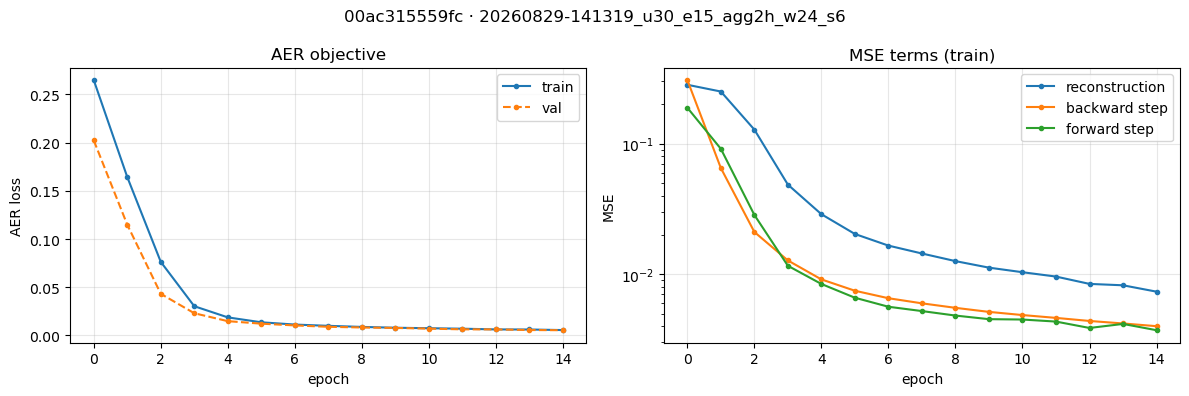

In [23]:
def plot_learning(loss_log: pd.DataFrame, title: str = ""):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    ax = axes[0]
    for split, style in (("train", "-"), ("val", "--")):
        d = loss_log[loss_log["split"] == split]
        if d["loss"].notna().any():
            ax.plot(d["epoch"], d["loss"], style, marker="o", ms=3, label=split)
    ax.set_xlabel("epoch"); ax.set_ylabel("AER loss")
    ax.set_title("AER objective"); ax.legend(); ax.grid(alpha=.3)

    ax = axes[1]
    d = loss_log[loss_log["split"] == "train"]
    for col, lbl in (("mse_recon", "reconstruction"), ("mse_backward", "backward step"),
                     ("mse_forward", "forward step")):
        ax.plot(d["epoch"], d[col], marker="o", ms=3, label=lbl)
    ax.set_xlabel("epoch"); ax.set_ylabel("MSE"); ax.set_yscale("log")
    ax.set_title("MSE terms (train)"); ax.legend(); ax.grid(alpha=.3)

    fig.suptitle(title or f"{WORLD_ID} · {RUN_ID}")
    fig.tight_layout()
    plt.show()


plot_learning(loss_log)


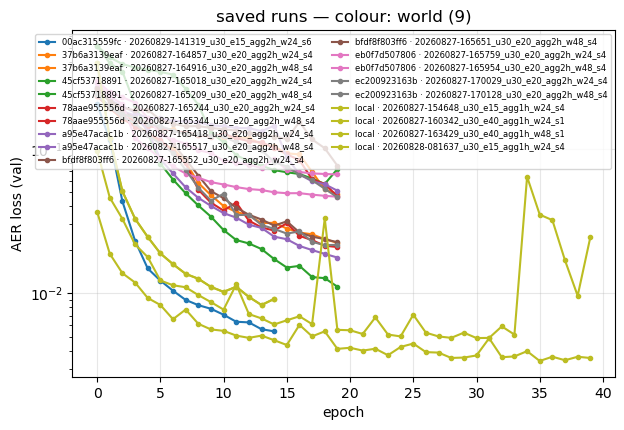

In [24]:
def compare_runs(run_ids: list[tuple[str, str]] | None = None, split: str = "val"):
    """Overlay the loss curves of several saved runs. `run_ids` = [(world_id, run_id), ...]."""
    run_ids = run_ids or list_runs()
    worlds = sorted({w for w, _ in run_ids})
    cmap = {w: plt.get_cmap("tab10")(i % 10) for i, w in enumerate(worlds)}
    fig, ax = plt.subplots(figsize=(7, 4.5))
    for w, rid in run_ids:
        log = pd.read_csv(SANDBOX / w / rid / "loss_history.csv")
        d = log[log["split"] == split]
        if d["loss"].notna().any():
            ax.plot(d["epoch"], d["loss"], marker="o", ms=3, color=cmap[w],
                    label=f"{w[:12]} · {rid}")
    ax.set_xlabel("epoch"); ax.set_ylabel(f"AER loss ({split})")
    ax.set_yscale("log"); ax.grid(alpha=.3)
    ax.legend(fontsize=6, loc="upper right", ncol=1 if len(worlds) <= 1 else 2)
    ax.set_title(f"saved runs — colour: world ({len(worlds)})")
    plt.show()


compare_runs()


## 7. Latent space explorer

`ipywidgets` + matplotlib. Pick a **world**, a saved **run**, a projection, an **epoch**, and what
to colour by:

* **client** — categorical; are the districts separated or entangled?
* **month** — the drift axis; a drifting district should smear along it late in the horizon.
* **hour** — hour of day at which the window starts (2h-aggregated windows start on even hours).

**Epoch scrubbing.** The slider walks the snapshots (`-1` = untrained init). *Aligned projection*
fits **one** projection on every epoch pooled and applies it to each, with axes fixed across
epochs — that is what makes the frames comparable; untick it to see each epoch on its own best axes.

*Final (all windows)* ignores the epoch and uses the fully-trained model over every window rather
than the snapshot subset. t-SNE / UMAP fit on the pooled epochs when aligned, so they get slow
quickly — drop *pts/epoch* before switching to them.


In [25]:
import ipywidgets as widgets
from IPython.display import display
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

try:
    import umap                    # optional
    HAS_UMAP = True
except Exception:
    HAS_UMAP = False

_LAT_CACHE = {(WORLD_ID, RUN_ID): latents}
_EPO_CACHE = {(WORLD_ID, RUN_ID): epoch_latents}
_EMB_CACHE: dict[tuple, dict] = {}

FCOLS = lambda df: [c for c in df.columns if c.startswith("f") and c[1:].isdigit()]


def get_latents(world_id: str, run_id: str) -> pd.DataFrame:
    key = (world_id, run_id)
    if key not in _LAT_CACHE:
        _LAT_CACHE[key] = load_run(world_id, run_id)[2]
    return _LAT_CACHE[key]


def get_epoch_latents(world_id: str, run_id: str):
    key = (world_id, run_id)
    if key not in _EPO_CACHE:
        _EPO_CACHE[key] = load_run(world_id, run_id)[3]
    return _EPO_CACHE[key]


def _fit_project(Z: np.ndarray, method: str, seed: int = 0):
    """-> (embedding, transform_fn or None, subtitle)."""
    scaler = StandardScaler().fit(Z)
    Zs = scaler.transform(Z)
    if method == "PCA":
        p = PCA(n_components=min(10, Zs.shape[1]), random_state=seed).fit(Zs)
        sub = "  ".join(f"PC{i+1} {v:.1%}" for i, v in enumerate(p.explained_variance_ratio_[:4]))
        return p.transform(Zs), (lambda A: p.transform(scaler.transform(A))), sub
    if method == "t-SNE":
        from sklearn.manifold import TSNE
        E = TSNE(n_components=2, init="pca", random_state=seed,
                perplexity=min(30, max(5, len(Zs) // 4))).fit_transform(Zs)
        return E, None, "t-SNE"
    E = umap.UMAP(n_components=2, random_state=seed).fit_transform(Zs)
    return E, None, "UMAP"


def epoch_embedding(world_id, run_id, method, clients, month_rng, pts_per_epoch, align, seed=0):
    """-> {"frames": {epoch: (df, E)}, "sub": str, "lims": (xlim, ylim) or None}."""
    key = (world_id, run_id, method, tuple(sorted(clients)), tuple(month_rng), pts_per_epoch, align)
    if key in _EMB_CACHE:
        return _EMB_CACHE[key]

    df = get_epoch_latents(world_id, run_id)
    d = df[df["district"].isin(list(clients)) & df["month"].between(*month_rng)].copy()
    if d.empty:
        raise ValueError("no snapshot rows for this filter")

    # keep the SAME windows in every epoch, so frames are comparable
    wid = d["district"].astype(str) + "#" + d["window"].astype(str)
    d = d.assign(_wid=wid)
    uniq = pd.Index(d["_wid"].unique())
    if len(uniq) > pts_per_epoch:
        keep = np.random.default_rng(seed).choice(uniq.to_numpy(), pts_per_epoch, replace=False)
        d = d[d["_wid"].isin(set(keep))]
    d = d.sort_values(["epoch", "district", "window"]).reset_index(drop=True)

    fcols = FCOLS(d)
    frames = {}
    if align:
        E_all, _, sub = _fit_project(d[fcols].to_numpy(), method, seed)
        for e, g in d.groupby("epoch", sort=True):
            frames[int(e)] = (g, E_all[g.index.to_numpy()])
        sub = f"{sub} (aligned)"
        pad = 0.05 * np.ptp(E_all[:, :2], axis=0)
        lims = ((E_all[:, 0].min() - pad[0], E_all[:, 0].max() + pad[0]),
                (E_all[:, 1].min() - pad[1], E_all[:, 1].max() + pad[1]))
    else:
        subs = []
        for e, g in d.groupby("epoch", sort=True):
            E, _, sub = _fit_project(g[fcols].to_numpy(), method, seed)
            frames[int(e)] = (g.reset_index(drop=True), E)
            subs.append(sub)
        sub = subs[-1] + " (per-epoch fit)"
        lims = None

    out = {"frames": frames, "sub": sub, "lims": lims}
    _EMB_CACHE[key] = out
    return out


def final_embedding(world_id, run_id, method, clients, month_rng, max_points, seed=0):
    key = ("final", world_id, run_id, method, tuple(sorted(clients)), tuple(month_rng), max_points)
    if key in _EMB_CACHE:
        return _EMB_CACHE[key]
    df = get_latents(world_id, run_id)
    d = df[df["district"].isin(list(clients)) & df["month"].between(*month_rng)]
    if d.empty:
        raise ValueError("no rows for this filter")
    if len(d) > max_points:
        d = d.sample(max_points, random_state=seed)
    d = d.sort_values(["district", "window"]).reset_index(drop=True)
    E, _, sub = _fit_project(d[FCOLS(d)].to_numpy(), method, seed)
    out = {"frames": {None: (d, E)}, "sub": sub, "lims": None}
    _EMB_CACHE[key] = out
    return out

AttributeError: module 'ml_dtypes' has no attribute 'float8_e4m3b11'

In [12]:
plt.ioff()


def _scatter(ax, d, E, ix, iy, color_by, size, alpha, fig, highlight=None):
    if color_by == "client":
        cmap = plt.get_cmap("tab10")
        for i, c in enumerate(sorted(d["district"].unique())):
            m = (d["district"] == c).to_numpy()
            ax.scatter(E[m, ix], E[m, iy], s=size, alpha=alpha, color=cmap(i % 10),
                      label=c, linewidths=0)
        ax.legend(markerscale=3, fontsize=8, framealpha=.9, loc="best")
    else:
        vals = d[color_by].to_numpy()
        cmap, vmin, vmax = ("twilight", 0, 24) if color_by == "hour" \
            else ("YlOrBr", vals.min(), vals.max())
        sc = ax.scatter(E[:, ix], E[:, iy], c=vals, s=size, alpha=alpha, cmap=cmap,
                        vmin=vmin, vmax=vmax, linewidths=0)
        cb = fig.colorbar(sc, ax=ax)
        cb.set_label("hour of day (window start)" if color_by == "hour" else "model month")
    if highlight is not None:
        hx, hy = highlight
        ax.scatter([hx], [hy], s=180, marker="*", facecolor="none",
                  edgecolor="black", linewidths=1.6, zorder=5)


def _bubble(ax, d, E, ix, iy, color_by, n_bins, alpha, fig, highlight = None):
    """Grid-aggregates the same points `_scatter` would draw: `n_bins` bins per axis,
    marker area ~ point count per bin, position = mean of the points it folds in. High
    n_bins degenerates toward plain scatter (most bins hold <=1 point); low n_bins gives
    a handful of large, coarse bubbles."""
    x, y = E[:, ix], E[:, iy]
    n_bins = max(2, int(n_bins))
    xe = np.linspace(x.min(), x.max(), n_bins + 1)
    ye = np.linspace(y.min(), y.max(), n_bins + 1)
    bx = np.clip(np.digitize(x, xe) - 1, 0, n_bins - 1)
    by = np.clip(np.digitize(y, ye) - 1, 0, n_bins - 1)
    bin_id = bx * n_bins + by

    rows = []
    districts = d["district"].to_numpy()
    vals = d[color_by].to_numpy() if color_by != "client" else None
    for b in np.unique(bin_id):
        m = bin_id == b
        row = {"x": x[m].mean(), "y": y[m].mean(), "count": int(m.sum())}
        if color_by == "client":
            u, c = np.unique(districts[m], return_counts=True)
            row["value"] = u[c.argmax()]          # majority client in the bin
        else:
            row["value"] = vals[m].mean()          # mean month/hour in the bin
        rows.append(row)
        bub = pd.DataFrame(rows)
    c = bub["count"].to_numpy()
    size = (np.full(len(c), 150.0) if c.max() == c.min()
           else 30 + 500 * (c - c.min()) / (c.max() - c.min()))   # area ~ count, normalized to this render

    if color_by == "client":
        clients = sorted(d["district"].unique())
        cmap = plt.get_cmap("tab10")
        colour_of = {c: cmap(i % 10) for i, c in enumerate(clients)}
        ax.scatter(bub["x"], bub["y"], s=size, alpha=alpha,
                  color=[colour_of[v] for v in bub["value"]], edgecolor="black", linewidths=0.4)
        handles = [plt.Line2D([0], [0], marker="o", ls="", color=colour_of[c], label=c)
                  for c in clients]
        ax.legend(handles=handles, markerscale=1.3, fontsize=8, framealpha=.9, loc="best")
    else:
        cmap, vmin, vmax = ("twilight", 0, 24) if color_by == "hour" \
            else ("YlOrBr", bub["value"].min(), bub["value"].max())
        sc = ax.scatter(bub["x"], bub["y"], s=size, c=bub["value"], alpha=alpha, cmap=cmap,
                        vmin=vmin, vmax=vmax, edgecolor="black", linewidths=0.4)
        cb = fig.colorbar(sc, ax=ax)
        cb.set_label("hour of day (window start)" if color_by == "hour" else "model month")

    if highlight is not None:
        ax.scatter([highlight[0]], [highlight[1]], s=180, marker="*", facecolor="none",
                  edgecolor="black", linewidths=1.6, zorder=5)

def plot_latent(world_id, run_id, color_by, method, comp_x, comp_y, clients, month_rng,
                epoch, use_final, align, max_points, size, alpha, bubble):
    clients = list(clients) or sorted(get_latents(world_id, run_id)["district"].unique())
    has_epochs = get_epoch_latents(world_id, run_id) is not None

    try:
        if use_final or not has_epochs:
            emb = final_embedding(world_id, run_id, method, clients, month_rng, max_points)
            d, E = emb["frames"][None]
            tag = "final model, all windows" + ("" if has_epochs else " — no snapshots saved")
        else:
            emb = epoch_embedding(world_id, run_id, method, clients, month_rng, max_points, align)
            avail = sorted(emb["frames"])
            e = min(avail, key=lambda a: abs(a - epoch))
            d, E = emb["frames"][e]
            tag = f"epoch {e}" + (" (untrained init)" if e < 0 else "")
    except ValueError as err:
        print(err); return

    if method == "PCA":
        ix, iy = min(comp_x, E.shape[1]) - 1, min(comp_y, E.shape[1]) - 1
        xl, yl = f"PC{ix+1}", f"PC{iy+1}"
    else:
        ix, iy, xl, yl = 0, 1, f"{method} 1", f"{method} 2"

    fig, ax = plt.subplots(figsize=(8.5, 6.5))
    if bubble:
        _bubble(ax, d, E, ix, iy, color_by, size, alpha, fig)
    else:
        _scatter(ax, d, E, ix, iy, color_by, size, alpha, fig)
    if emb["lims"] and method == "PCA" and (ix, iy) == (0, 1):
        ax.set_xlim(*emb["lims"][0]); ax.set_ylim(*emb["lims"][1])
    ax.set_xlabel(xl); ax.set_ylabel(yl); ax.grid(alpha=.2)
    mode = f"bubble, bins={size}" if bubble else f"scatter, size={size}"
    ax.set_title(f"{world_id[:12]} · {run_id}\n{tag}  |  {len(d)} windows  |  colour: {color_by}"
                f"  |  {mode}  |  {emb['sub']}", fontsize=10)
    fig.tight_layout()
    display(fig)
    plt.close(fig)


In [13]:
def _init_state(consumption_map: str, district: str) -> str:
    """'LL_LM_LL_LL_LM', 'District_B' -> 'LM'
     (that district's own token)."""
    idx = ord(district[-1]) - ord("A")
    return consumption_map.split("_")[idx]


def _world_label(sim_hash: str, meta: dict) -> str:
    if not meta:                                    # "local" pseudo-world
        return "local"
    d, cmap = meta.get("drift_district"), meta.get("consumption_map", "?")
    init = _init_state(cmap, d) if d else "??"
    final = f"{meta.get('drift_to_income', '?')[0].upper()}{meta.get('drift_to_density', '?')[0].upper()}"
    return (f"{d[-1]}_{init}_{final}___{cmap}___{meta.get('variant', '?')[:4]}"
           f"__{sim_hash[:6]}") #__seed{meta.get('sim_seed', '?')}

runs = list_runs()
world_ids = sorted({w for w, _ in runs})
world_names = [_world_label(w, WORLDS[w]["meta"]) for w in world_ids]

DEFAULT_WORLD = WORLD_ID if WORLD_ID in world_ids else world_ids[0]
DEFAULT_RUN = RUN_ID if (WORLD_ID, RUN_ID) in runs else next(r for w, r in runs if w == DEFAULT_WORLD)

df0, ep0 = get_latents(DEFAULT_WORLD, DEFAULT_RUN), get_epoch_latents(DEFAULT_WORLD, DEFAULT_RUN)
all_clients = sorted(df0["district"].unique())
m_lo, m_hi = int(df0["month"].min()), int(df0["month"].max())
e_lo, e_hi = (int(ep0["epoch"].min()), int(ep0["epoch"].max())) if ep0 is not None else (-1, -1)

w_world = widgets.Dropdown(options=sorted(list(zip(world_names, world_ids))), value=DEFAULT_WORLD,
                           description="world:", layout=widgets.Layout(width="330px"))
w_run = widgets.Dropdown(options=[r for w, r in runs if w == DEFAULT_WORLD], value=DEFAULT_RUN,
                         description="run:", layout=widgets.Layout(width="430px"))
w_color = widgets.ToggleButtons(options=["client", "month", "hour"], value="client",
                                description="colour by:")
w_method = widgets.Dropdown(options=["PCA", "t-SNE"] + (["UMAP"] if HAS_UMAP else []),
                            value="PCA", description="projection:")
w_cx = widgets.IntSlider(value=1, min=1, max=10, description="x comp:")
w_cy = widgets.IntSlider(value=2, min=1, max=10, description="y comp:")
w_clients = widgets.SelectMultiple(options=all_clients, value=tuple(all_clients),
                                   description="clients:", rows=min(6, len(all_clients)))
w_months = widgets.IntRangeSlider(value=[m_lo, m_hi], min=m_lo, max=m_hi,
                                  description="months:", continuous_update=False)
w_epoch = widgets.IntSlider(value=e_hi, min=e_lo, max=e_hi, description="epoch:",
                            continuous_update=False)
w_play = widgets.Play(value=e_hi, min=e_lo, max=e_hi, interval=900, description="play")
widgets.jslink((w_play, "value"), (w_epoch, "value"))
w_final = widgets.Checkbox(value=False, description="final (all windows)", indent=False)
w_align = widgets.Checkbox(value=True, description="aligned projection", indent=False)
w_bubble = widgets.Checkbox(value=False, description="bubble plot", indent=False)
w_size = widgets.IntSlider(value=8, min=1, max=60, step=1, description="size:")   # size <-> bins
w_alpha = widgets.FloatSlider(value=0.7, min=0.05, max=1.0, step=0.05, description="alpha:")


def _on_bubble_change(change):
    """Repurposes w_size: point size in scatter mode, bin count per axis in bubble mode."""
    bubble = change["new"]
    lo, hi = (3, 40) if bubble else (1, 60)
    w_size.description = "bins:" if bubble else "size:"
    if lo > w_size.max:                      # widen/narrow in the order that can't hit min>max
        w_size.max = hi; w_size.min = lo
    else:
        w_size.min = lo; w_size.max = hi
    w_size.value = min(max(w_size.value, lo), hi)


w_bubble.observe(_on_bubble_change, names="value")


def _retarget(world_id, run_id):
    """Point the epoch/month/client controls at a (world, run)."""
    lat, epo = get_latents(world_id, run_id), get_epoch_latents(world_id, run_id)
    cs = sorted(lat["district"].unique())
    w_clients.options = cs
    w_clients.value = tuple(cs)
    lo, hi = int(lat["month"].min()), int(lat["month"].max())
    w_months.max = max(hi, w_months.min); w_months.min = lo; w_months.max = hi
    w_months.value = [lo, hi]
    if epo is None:
        w_final.value = True
        w_epoch.disabled = w_play.disabled = True
    else:
        el, eh = int(epo["epoch"].min()), int(epo["epoch"].max())
        for w in (w_epoch, w_play):
            w.max = max(eh, w.min); w.min = el; w.max = eh
            w.disabled = False
        w_epoch.value = eh
        w_final.value = False


def _on_world_change(change):
    opts = [r for w, r in runs if w == change["new"]]
    w_run.options = sorted(opts)
    w_run.value = opts[0]


def _on_run_change(change):
    _retarget(w_world.value, change["new"])


w_world.observe(_on_world_change, names="value")
w_run.observe(_on_run_change, names="value")

out = widgets.interactive_output(plot_latent, {
    "world_id": w_world, "run_id": w_run, "color_by": w_color, "method": w_method,
    "comp_x": w_cx, "comp_y": w_cy, "clients": w_clients, "month_rng": w_months,
    "epoch": w_epoch, "use_final": w_final, "align": w_align,
    "max_points": widgets.fixed(1200), "size": w_size, "alpha": w_alpha, "bubble": w_bubble,
})

controls = widgets.VBox([
    widgets.HBox([w_world, w_run]),
    widgets.HBox([w_color, w_method]),
    widgets.HBox([w_play, w_epoch, w_final, w_align]),
    widgets.HBox([w_cx, w_cy]),
    widgets.HBox([w_clients, w_months]),
    widgets.HBox([w_bubble, w_size, w_alpha]),
])
display(controls, out)

Output()

### Static grids (for export)

`latent_grid()` — the three colourings of one epoch side by side.
`epoch_grid()` — one colouring across epochs, on the aligned projection, which is the clearest
single picture of *how* the latent space organised itself.


In [21]:
# def latent_grid(world_id=None, run_id=None, method="PCA", epoch=None, use_final=False,
#                max_points=1500):
#     world_id, run_id = world_id or WORLD_ID, run_id or RUN_ID
#     lat = get_latents(world_id, run_id)
#     clients = tuple(sorted(lat["district"].unique()))
#     months = (int(lat["month"].min()), int(lat["month"].max()))
#     epo = get_epoch_latents(world_id, run_id)
#     epoch = epoch if epoch is not None else (int(epo["epoch"].max()) if epo is not None else -1)
#     for color_by in ("client", "month", "hour"):
#         plot_latent(world_id, run_id, color_by, method, 1, 2, clients, months,
#                    epoch, use_final, True, max_points, 8, 0.7)


# def epoch_grid(world_id=None, run_id=None, color_by="client", epochs=None, method="PCA",
#               pts_per_epoch=800, ncols=4, size=6, alpha=0.7):
#     world_id, run_id = world_id or WORLD_ID, run_id or RUN_ID
#     lat = get_latents(world_id, run_id)
#     clients = sorted(lat["district"].unique())
#     months = (int(lat["month"].min()), int(lat["month"].max()))
#     emb = epoch_embedding(world_id, run_id, method, clients, months, pts_per_epoch, align=True)
#     eps = epochs or sorted(emb["frames"])
#     nrows = int(np.ceil(len(eps) / ncols))
#     fig, axes = plt.subplots(nrows, ncols, figsize=(3.3 * ncols, 3.1 * nrows),
#                              squeeze=False, sharex=True, sharey=True)
#     for ax, e in zip(axes.ravel(), eps):
#         d, E = emb["frames"][e]
#         _scatter(ax, d, E, 0, 1, color_by, size, alpha, fig)
#         if color_by == "client" and e != eps[0]:
#             ax.get_legend().remove()
#         ax.set_title(f"epoch {e}" + (" (init)" if e < 0 else ""), fontsize=9)
#         if emb["lims"]:
#             ax.set_xlim(*emb["lims"][0]); ax.set_ylim(*emb["lims"][1])
#         ax.grid(alpha=.2)
#     for ax in axes.ravel()[len(eps):]:
#         ax.axis("off")
#     fig.suptitle(f"{world_id[:12]} · {run_id} — colour: {color_by} — {emb['sub']}", fontsize=10)
#     fig.tight_layout()
#     plt.show()


# latent_grid()
# epoch_grid(color_by="client")


## 8. Raw ↔ latent cross-view

Two independent panels, each a full copy of Section 7's controls — pick **any** (world, run) in
each, including the same run twice. A window is picked by **district + a target native time-step**
(not a raw click — this stays in the same dial-driven, static-figure idiom as the rest of the
notebook) and highlighted with a star on both latent scatters, with its **raw sensor trace**
plotted underneath each panel.

*sync panels* links panel B's district / target-step / colour controls to panel A's — turn it off
and B's own copies reappear, independent. Matching is by **nearest available window**
(`window_start_step` closest to the target) per panel, independently, since two panels can use
different `step_size` / `window_size` and rarely land on the exact same start.


In [14]:
_RAW_CACHE: dict[tuple, pd.DataFrame] = {}
_CFG_CACHE: dict[tuple, dict] = {}


def get_drift_onset(world_id: str) -> tuple[str | None, int | None]:
    """(drift_district, onset_month) — onset = warmup_months + 1 (the schedule's
    deterministic start; how far it's spread by a later month is stochastic, the
    start month isn't). (None, None) if unknown. Falls back to reading the world's
    manifest.json straight off disk if it isn't cached in WORLDS[world_id]."""
    if world_id == "local":
        drift = dict(BASE_PARAMS.get("scenario", {}).get("drift", {}))
        local_path = ROOT / "conf" / "local" / "parameters.yml"
        if local_path.exists():
            local_cfg = yaml.safe_load(local_path.read_text()) or {}
            drift.update((local_cfg.get("scenario") or {}).get("drift", {}))
    else:
        man = WORLDS.get(world_id, {}).get("manifest")
        if not man:
            mpath = ROOT / "data" / "09_experiments" / "worlds" / world_id / "manifest.json"
            man = json.loads(mpath.read_text()) if mpath.exists() else {}
        drift = ((man.get("effective") or {}).get("scenario") or {}).get("drift", {})
    district = drift.get("tgt_district")
    warmup = drift.get("warmup_months")
    return district, (int(warmup) + 1 if warmup is not None else None)


def get_raw_client(world_id: str, district: str) -> pd.DataFrame:
    key = (world_id, district)
    if key not in _RAW_CACHE:
        _RAW_CACHE[key] = pd.read_csv(WORLDS[world_id]["client_dir"] / f"{district}.csv")
    return _RAW_CACHE[key]


def get_run_config(world_id: str, run_id: str) -> dict:
    key = (world_id, run_id)
    if key not in _CFG_CACHE:
        _CFG_CACHE[key] = json.loads((SANDBOX / world_id / run_id / "config.json").read_text())
    return _CFG_CACHE[key]


def nearest_window(world_id: str, run_id: str, district: str, month: int, day_of_month: int):
    """-> (window_start_step, row) — saved window for `district` closest in calendar
    time to (month, day_of_month). `day_of_month` is 1-indexed (UI-facing); the
    stored column is 0-indexed, converted below."""
    lat = get_latents(world_id, run_id)
    d = lat[lat["district"] == district]
    if d.empty:
        return None, None
    dpm = TIME["days_per_month"]
    target = month * dpm + (day_of_month - 1)
    idx = (d["month"] * dpm + d["day_of_month"] - target).abs().idxmin()
    row = d.loc[idx]
    return int(row["window"]), row


def get_raw_day(world_id: str, district: str, month: int, day_of_month: int) -> pd.DataFrame:
    """Exactly one calendar day's raw trace — independent of any run's window_size.
    Assumes the raw client CSV's own 'month' column matches fl_preprocessing's month
    numbering, and every month has exactly TIME['days_per_month'] days — both true by
    construction here, worth a one-time eyeball check against real data."""
    df = get_raw_client(world_id, district)
    month_rows = df[df["month"] == month].reset_index(drop=True)
    steps_per_day = round(24 / TIME["resolution_h"])
    start = (day_of_month - 1) * steps_per_day
    return month_rows.iloc[start: start + steps_per_day].reset_index(drop=True)


def get_raw_window_span(world_id: str, run_id: str, district: str, window_start_step: int) -> pd.DataFrame:
    """Fallback: the full saved-window span (this run's window_size)."""
    cfg = get_run_config(world_id, run_id)
    interval_agg_h = cfg["preprocessing"]["interval_agg_h"]
    window_size = cfg["preprocessing"]["window_size"]
    native_per_agg = max(1, round(interval_agg_h / TIME["resolution_h"]))
    span = window_size * native_per_agg
    df = get_raw_client(world_id, district)
    return df.iloc[window_start_step: window_start_step + span].reset_index(drop=True)

In [15]:
def _plot_raw(ax, seg: pd.DataFrame, title: str):
    p_cols = [c for c in seg.columns if c.startswith("p_")]
    q_cols = [c for c in seg.columns if c.startswith("q_")]
    x = np.arange(len(seg))
    for c in p_cols:
        ax.plot(x, seg[c], lw=1.2, label=c)
    ax.set_ylabel("pressure"); ax.set_xlabel("native step")
    if q_cols:
        ax2 = ax.twinx()
        for c in q_cols:
            ax2.plot(x, seg[c], lw=1.2, ls="--", label=c)
        ax2.set_ylabel("flow")
        lines = ax.get_lines() + ax2.get_lines()
        ax.legend(lines, [l.get_label() for l in lines], fontsize=7, loc="upper right")
    elif p_cols:
        ax.legend(fontsize=7, loc="upper right")
    ax.set_title(title, fontsize=9)
    ax.grid(alpha=.2)


def _scatter(ax, d, E, ix, iy, color_by, size, alpha, fig, highlight_month=None):
    """`highlight_month`, if given, renders that month at alpha=1 with a thin black edge
    (drawn on top) and dims everything else to `alpha`. `highlight_month=None` reproduces
    the plain single-pass rendering (used by Sections 6/7, unaffected by this)."""
    n = len(d)
    fg = (d["month"] == highlight_month).to_numpy() if highlight_month is not None else np.zeros(n, dtype=bool)
    bg = ~fg

    if color_by == "client":
        clients = sorted(d["district"].unique())
        cmap = plt.get_cmap("tab10")
        colour_of = {c: cmap(i % 10) for i, c in enumerate(clients)}
        districts = d["district"].to_numpy()
        for c in clients:
            m_bg = bg & (districts == c)
            m_fg = fg & (districts == c)
            if m_bg.any():
                ax.scatter(E[m_bg, ix], E[m_bg, iy], s=size, alpha=alpha, color=colour_of[c],
                          linewidths=0, zorder=2)
            if m_fg.any():
                ax.scatter(E[m_fg, ix], E[m_fg, iy], s=size, alpha=1.0, color=colour_of[c],
                          edgecolor="black", linewidths=0.8, zorder=3)
        handles = [plt.Line2D([0], [0], marker="o", ls="", color=colour_of[c], label=c) for c in clients]
        ax.legend(handles=handles, markerscale=3, fontsize=8, framealpha=.9, loc="best")
    else:
        vals = d[color_by].to_numpy()
        cmap, vmin, vmax = ("twilight", 0, 24) if color_by == "hour" else ("YlOrBr", vals.min(), vals.max())
        sc = None
        if bg.any():
            sc = ax.scatter(E[bg, ix], E[bg, iy], c=vals[bg], s=size, alpha=alpha, cmap=cmap,
                            vmin=vmin, vmax=vmax, linewidths=0, zorder=2)
        if fg.any():
            sc_fg = ax.scatter(E[fg, ix], E[fg, iy], c=vals[fg], s=size, alpha=1.0, cmap=cmap,
                               vmin=vmin, vmax=vmax, linewidths=0.8, edgecolor="black", zorder=3)
            sc = sc if sc is not None else sc_fg
        cb = fig.colorbar(sc, ax=ax)
        cb.set_label("hour of day (window start)" if color_by == "hour" else "model month")


def _bin(sub_d, sub_E, ix, iy, color_by, n_bins):
    x, y = sub_E[:, ix], sub_E[:, iy]
    n_bins = max(2, int(n_bins))
    xe = np.linspace(x.min(), x.max(), n_bins + 1)
    ye = np.linspace(y.min(), y.max(), n_bins + 1)
    bx = np.clip(np.digitize(x, xe) - 1, 0, n_bins - 1)
    by = np.clip(np.digitize(y, ye) - 1, 0, n_bins - 1)
    bin_id = bx * n_bins + by
    rows = []
    districts = sub_d["district"].to_numpy()
    vals = sub_d[color_by].to_numpy() if color_by != "client" else None
    for b in np.unique(bin_id):
        m = bin_id == b
        row = {"x": x[m].mean(), "y": y[m].mean(), "count": int(m.sum())}
        if color_by == "client":
            u, c = np.unique(districts[m], return_counts=True)
            row["value"] = u[c.argmax()]
        else:
            row["value"] = vals[m].mean()
        rows.append(row)
    bub = pd.DataFrame(rows)
    c = bub["count"].to_numpy()
    bub["size"] = (np.full(len(c), 150.0) if c.max() == c.min()
                  else 30 + 500 * (c - c.min()) / (c.max() - c.min()))
    return bub


def _bubble(ax, d, E, ix, iy, color_by, n_bins, alpha, fig, highlight_month=None):
    """Same background/foreground split as `_scatter`, binned independently — the
    highlighted month's own aggregate shape, crisp and edged, over the dimmed rest."""
    n = len(d)
    fg_mask = (d["month"] == highlight_month).to_numpy() if highlight_month is not None else np.zeros(n, dtype=bool)
    bg_mask = ~fg_mask
    clients = sorted(d["district"].unique())
    cmap_of = ("twilight", 0, 24) if color_by == "hour" else (
        ("YlOrBr", None, None) if color_by != "client" else (None, None, None))

    def _draw(mask, edge, alph):
        if not mask.any():
            return None
        bub = _bin(d[mask], E[mask], ix, iy, color_by, n_bins)
        if color_by == "client":
            palette = plt.get_cmap("tab10")
            colour_of = {c: palette(i % 10) for i, c in enumerate(clients)}
            ax.scatter(bub["x"], bub["y"], s=bub["size"], alpha=alph,
                      color=[colour_of[v] for v in bub["value"]],
                      edgecolor="black" if edge else "none", linewidths=0.8 if edge else 0.4,
                      zorder=3 if edge else 2)
            return None
        cmap, vmin, vmax = cmap_of
        if vmin is None:
            vmin, vmax = d[color_by].min(), d[color_by].max()
        return ax.scatter(bub["x"], bub["y"], s=bub["size"], c=bub["value"], alpha=alph, cmap=cmap,
                          vmin=vmin, vmax=vmax, edgecolor="black" if edge else "none",
                          linewidths=0.8 if edge else 0.4, zorder=3 if edge else 2)

    sc_bg = _draw(bg_mask, edge=False, alph=alpha)
    sc_fg = _draw(fg_mask, edge=True, alph=1.0)

    if color_by == "client":
        palette = plt.get_cmap("tab10")
        handles = [plt.Line2D([0], [0], marker="o", ls="", color=palette(i % 10), label=c)
                  for i, c in enumerate(clients)]
        ax.legend(handles=handles, markerscale=1.3, fontsize=8, framealpha=.9, loc="best")
    else:
        cb = fig.colorbar(sc_bg if sc_bg is not None else sc_fg, ax=ax)
        cb.set_label("hour of day (window start)" if color_by == "hour" else "model month")


def _panel(ax_lat, ax_raw, world_id, run_id, method, clients, month_rng,
          epoch, align, max_points, size, alpha, bubble, color_by,
          district, month, day, raw_mode):
    clients = list(clients) or sorted(get_latents(world_id, run_id)["district"].unique())
    has_epochs = get_epoch_latents(world_id, run_id) is not None
    try:
        if not has_epochs:
            emb = final_embedding(world_id, run_id, method, clients, month_rng, max_points)
            d, E = emb["frames"][None]
            tag = "final (no snapshots saved)"
        else:
            emb = epoch_embedding(world_id, run_id, method, clients, month_rng, max_points, align)
            avail = sorted(emb["frames"])
            e = min(avail, key=lambda a: abs(a - epoch))
            d, E = emb["frames"][e]
            tag = f"epoch {e}" + (" (untrained init)" if e < 0
                                  else " (final)" if e == avail[-1] else "")
    except ValueError as err:
        ax_lat.text(0.5, 0.5, str(err), ha="center", transform=ax_lat.transAxes)
        ax_raw.axis("off")
        return

    ix, iy = 0, 1
    (_bubble if bubble else _scatter)(ax_lat, d, E, ix, iy, color_by, size, alpha,
                                      ax_lat.figure, highlight_month=month)
    xl, yl = ("PC1", "PC2") if method == "PCA" else (f"{method} 1", f"{method} 2")
    ax_lat.set_xlabel(xl); ax_lat.set_ylabel(yl)
    ax_lat.set_title(f"{WORLD_LABELS.get(world_id, world_id)}\n{run_id} · {tag}  |  colour: {color_by}"
                     f"  |  highlight: month {month}", fontsize=9)
    ax_lat.grid(alpha=.2)

    ws, _ = nearest_window(world_id, run_id, district, month, day)
    if ws is None:
        ax_raw.text(0.5, 0.5, f"no windows for {district}", ha="center", transform=ax_raw.transAxes)
        ax_raw.axis("off")
        return
    if raw_mode == "day":
        seg = get_raw_day(world_id, district, month, day)
        span_note = f"month {month}, day {day}"
    else:
        seg = get_raw_window_span(world_id, run_id, district, ws)
        span_note = f"native step {ws} (saved window span)"
    _plot_raw(ax_raw, seg, f"{district}  ·  {span_note}")


def dual_view(A_world, A_run, A_method, A_clients, A_months, A_epoch, A_align,
             A_max, A_size, A_alpha, A_bubble, A_district, A_month, A_day, A_color, A_raw_mode,
             B_world, B_run, B_method, B_clients, B_months, B_epoch, B_align,
             B_max, B_size, B_alpha, B_bubble, B_district, B_month, B_day, B_color, B_raw_mode):
    fig, axes = plt.subplots(2, 2, figsize=(13, 8.5), gridspec_kw={"height_ratios": [3, 1.4]})
    _panel(axes[0, 0], axes[1, 0], A_world, A_run, A_method, A_clients, A_months,
          A_epoch, A_align, A_max, A_size, A_alpha, A_bubble, A_color,
          A_district, A_month, A_day, A_raw_mode)
    _panel(axes[0, 1], axes[1, 1], B_world, B_run, B_method, B_clients, B_months,
          B_epoch, B_align, B_max, B_size, B_alpha, B_bubble, B_color,
          B_district, B_month, B_day, B_raw_mode)
    fig.tight_layout()
    display(fig)
    plt.close(fig)

In [16]:
def _panel_controls(default_world, default_run):
    lat = get_latents(default_world, default_run)
    m_lo, m_hi = int(lat["month"].min()), int(lat["month"].max())
    cs = sorted(lat["district"].unique())
    return {
        "world": widgets.Dropdown(options=list(zip(world_names, world_ids)), value=default_world,
                                  description="world:", layout=widgets.Layout(width="280px")),
        "run": widgets.Dropdown(options=[r for w, r in runs if w == default_world],
                                value=default_run, description="run:",
                                layout=widgets.Layout(width="330px")),
        "method": widgets.Dropdown(options=["PCA", "t-SNE"] + (["UMAP"] if HAS_UMAP else []),
                                   value="PCA", description="proj:"),
        "clients": widgets.SelectMultiple(options=cs, value=tuple(cs), description="clients:",
                                          rows=min(5, len(cs))),
        "months": widgets.IntRangeSlider(value=[m_lo, m_hi], min=m_lo, max=m_hi,
                                         description="months:", continuous_update=False),
        "align": widgets.Checkbox(value=True, description="aligned", indent=False),
        "max_pts": widgets.IntSlider(value=1200, min=100, max=8000, step=100, description="pts:",
                                     continuous_update=False),
    }


def _retarget_panel(ctrl, world_id, run_id):
    lat = get_latents(world_id, run_id)
    cs = sorted(lat["district"].unique())
    ctrl["clients"].options = cs; ctrl["clients"].value = tuple(cs)
    lo, hi = int(lat["month"].min()), int(lat["month"].max())
    ctrl["months"].max = max(hi, ctrl["months"].min); ctrl["months"].min = lo
    ctrl["months"].max = hi; ctrl["months"].value = [lo, hi]


def _wire_panel(ctrl):
    def _on_world(change):
        opts = [r for w, r in runs if w == change["new"]]
        ctrl["run"].options = opts
        ctrl["run"].value = opts[0]

    def _on_run(change):
        _retarget_panel(ctrl, ctrl["world"].value, change["new"])

    ctrl["world"].observe(_on_world, names="value")
    ctrl["run"].observe(_on_run, names="value")


A = _panel_controls(DEFAULT_WORLD, DEFAULT_RUN)
B = _panel_controls(DEFAULT_WORLD, DEFAULT_RUN)
_wire_panel(A); _wire_panel(B)



# --- rendering controls: unified across both panels (not per-panel) -----------------------
shared_bubble = widgets.Checkbox(value=False, description="bubble", indent=False)
shared_size = widgets.IntSlider(value=8, min=1, max=60, step=1, description="size:")
shared_alpha = widgets.FloatSlider(value=0.7, min=0.05, max=1.0, step=0.05, description="alpha:")


def _on_bubble(change):
    bubble = change["new"]
    lo, hi = (3, 40) if bubble else (1, 60)
    shared_size.description = "bins:" if bubble else "size:"
    if lo > shared_size.max:
        shared_size.max = hi; shared_size.min = lo
    else:
        shared_size.min = lo; shared_size.max = hi
    shared_size.value = min(max(shared_size.value, lo), hi)


shared_bubble.observe(_on_bubble, names="value")

_epoch_capable = [(w, r) for w, r in runs if get_epoch_latents(w, r) is not None]
HAS_ANY_EPOCHS = bool(_epoch_capable)
if HAS_ANY_EPOCHS:
    epoch_lo = min(int(get_epoch_latents(w, r)["epoch"].min()) for w, r in _epoch_capable)
    epoch_hi = max(int(get_epoch_latents(w, r)["epoch"].max()) for w, r in _epoch_capable)
else:
    epoch_lo = epoch_hi = -1

shared_epoch = widgets.IntSlider(value=epoch_hi, min=epoch_lo, max=epoch_hi, description="epoch:",
                                 continuous_update=False, disabled=not HAS_ANY_EPOCHS)
shared_play = widgets.Play(value=epoch_hi, min=epoch_lo, max=epoch_hi, interval=900,
                           disabled=not HAS_ANY_EPOCHS)
widgets.jslink((shared_play, "value"), (shared_epoch, "value"))

shared_render_row = widgets.HBox([shared_bubble, shared_size, shared_alpha, shared_play, shared_epoch])



# --- the shared "which window" row: two independent copies, optionally linked -------------
all_districts = sorted({d for w, r in runs for d in get_latents(w, r)["district"].unique()})
month_lo = int(min(get_latents(w, r)["month"].min() for w, r in runs))
month_hi = int(max(get_latents(w, r)["month"].max() for w, r in runs))
days_per_month = TIME["days_per_month"]


def _shared_row(default_district):
    return {
        "district": widgets.Dropdown(options=all_districts, value=default_district,
                                     description="district:"),
        "month": widgets.IntSlider(value=month_lo, min=month_lo, max=month_hi,
                                   description="month:", continuous_update=False),
        "day": widgets.IntSlider(value=1, min=1, max=days_per_month, description="day:",
                                 continuous_update=False),
        "color": widgets.ToggleButtons(options=["client", "month", "hour"], value="month",
                                       description="colour:"),
        "raw_mode": widgets.ToggleButtons(options=["day", "window"], value="day",
                                          description="raw view:"),
    }


A_shared = _shared_row(all_districts[0])
B_shared = _shared_row(all_districts[0])
sync_box = widgets.Checkbox(value=True, description="sync panels", indent=False)
before_btn = widgets.Button(description="◀ before", layout=widgets.Layout(width="90px"))
after_btn = widgets.Button(description="after ▶", layout=widgets.Layout(width="90px"))
onset_info = widgets.HTML()

_LINKS: list = []
WORLD_LABELS = dict(zip(world_ids, world_names))   # world_id -> the exact dropdown label

a_shared_row = widgets.HBox([A_shared["district"], A_shared["month"], A_shared["color"]])
a_action_row = widgets.HBox([before_btn, after_btn, sync_box])
b_shared_row = widgets.HBox([B_shared["district"], B_shared["month"], B_shared["color"]])
a_raw_row = widgets.HBox([A_shared["day"], A_shared["raw_mode"]])
b_raw_row = widgets.HBox([B_shared["day"], B_shared["raw_mode"]])


def _apply_sync(change=None):
    for l in _LINKS:
        l.unlink()
    _LINKS.clear()
    if sync_box.value:
        for k in A_shared:
            _LINKS.append(widgets.link((A_shared[k], "value"), (B_shared[k], "value")))
    b_shared_row.layout.display = "none" if sync_box.value else "flex"
    b_raw_row.layout.display = "none" if sync_box.value else "flex"


def _update_onset_info(*_):
    district, onset = get_drift_onset(A["world"].value)
    if district is None:
        onset_info.value = "<i>drift schedule unknown for this world</i>"
    elif onset is None:
        onset_info.value = f"<b>{district}</b> drifts in this world — onset month unknown"
    else:
        picked = A_shared["district"].value
        onset_info.value = (f"<b>{district}</b> drifts starting month <b>{onset}</b> in this world"
                            + ("" if picked == district else f"  (currently viewing {picked})"))


def _jump_to_onset(offset):
    district, onset = get_drift_onset(A["world"].value)
    if onset is None:
        return
    if district in all_districts:
        A_shared["district"].value = district
    A_shared["month"].value = max(A_shared["month"].min, min(A_shared["month"].max, onset + offset))


before_btn.on_click(lambda _: _jump_to_onset(-1))
after_btn.on_click(lambda _: _jump_to_onset(1))
sync_box.observe(_apply_sync, names="value")
A["world"].observe(_update_onset_info, names="value")
A_shared["district"].observe(_update_onset_info, names="value")
A_shared["month"].observe(_update_onset_info, names="value")
_apply_sync()
_update_onset_info()

out2 = widgets.interactive_output(dual_view, {
    "A_world": A["world"], "A_run": A["run"], "A_method": A["method"],
    "A_clients": A["clients"], "A_months": A["months"], "A_epoch": shared_epoch,
    "A_align": A["align"], "A_max": A["max_pts"],
    "A_size": shared_size, "A_alpha": shared_alpha, "A_bubble": shared_bubble,
    "A_district": A_shared["district"], "A_month": A_shared["month"], "A_day": A_shared["day"],
    "A_color": A_shared["color"], "A_raw_mode": A_shared["raw_mode"],
    "B_world": B["world"], "B_run": B["run"], "B_method": B["method"],
    "B_clients": B["clients"], "B_months": B["months"], "B_epoch": shared_epoch,
    "B_align": B["align"], "B_max": B["max_pts"],
    "B_size": shared_size, "B_alpha": shared_alpha, "B_bubble": shared_bubble,
    "B_district": B_shared["district"], "B_month": B_shared["month"], "B_day": B_shared["day"],
    "B_color": B_shared["color"], "B_raw_mode": B_shared["raw_mode"],
})


def _panel_box(ctrl):
    return widgets.VBox([
        widgets.HBox([ctrl["world"], ctrl["run"]]),
        widgets.HBox([ctrl["method"], ctrl["align"]]),
        widgets.HBox([ctrl["clients"], ctrl["months"]]),
    ])


display(widgets.VBox([
    onset_info, a_shared_row, a_action_row, b_shared_row,
    shared_render_row,
    widgets.HBox([_panel_box(A), _panel_box(B)]),
]), out2, widgets.VBox([a_raw_row, b_raw_row]))

Output()

## 9. Sweep across worlds (optional)

Trains several `(world, config)` combinations in one go; each is saved to its own
`model_sandbox/<world_id>/<run_id>/` and appended to the shared `runs.csv`, so Sections 6–8 pick
them up (re-run their widget cells afterwards to refresh the dropdowns).


In [34]:
import copy


def sweep(worlds: list[str], overrides: list[dict], base: dict = None):
    """`worlds` = keys into WORLDS. `overrides` = list of {"model.lstm_units": 60, ...} dicts.
    Trains every (world, override) combination — len(worlds) x len(overrides) runs."""
    base = base or CONFIG
    done = []
    for world_id in worlds:
        cdfs = load_clients(WORLDS[world_id]["client_dir"])
        for ov in overrides:
            cfg = copy.deepcopy(base)
            cfg["world"] = world_id
            for dotted, val in ov.items():
                section, key = dotted.split(".")
                cfg[section][key] = val
            cfg["run_name"] = None
            print(f"\n=== {world_id[:12]} · {ov} ===")
            fw, sc, _ = build_windows(cdfs, cfg)
            meta, Xs = window_metadata(fw), pool_windows(fw)
            mdl, log, epo = train_aer(Xs, meta, cfg, verbose=False)
            lat = extract_latents(mdl, Xs, meta)
            done.append((world_id, save_run(mdl, log, lat, cfg, fw, sc, world_id, epo).name))
    return done


sweep(
    list(WORLDS.keys())[1:],
    [
        # {"model.lstm_units": 30, "training.epochs": 40},
        # {"model.lstm_units": 60, "training.epochs": 40},
        {"model.lstm_units": 30, "training.epochs": 20, "preprocessing.window_size": 24,
                 "preprocessing.interval_agg_h": 2, "preprocessing.step_size": 4},
        {"model.lstm_units": 30, "training.epochs": 20, "preprocessing.window_size": 48,
                 "preprocessing.interval_agg_h": 2, "preprocessing.step_size": 4},
    ],
)



=== 37b6a3139eaf · {'model.lstm_units': 30, 'training.epochs': 20, 'preprocessing.window_size': 24, 'preprocessing.interval_agg_h': 2, 'preprocessing.step_size': 4} ===
saved -> c:\Users\arthu\USPy\10_Mestrado\experiments\fedWater\notebooks\prospection\model_sandbox\37b6a3139eaf\20260827-164857_u30_e20_agg2h_w24_s4

=== 37b6a3139eaf · {'model.lstm_units': 30, 'training.epochs': 20, 'preprocessing.window_size': 48, 'preprocessing.interval_agg_h': 2, 'preprocessing.step_size': 4} ===
saved -> c:\Users\arthu\USPy\10_Mestrado\experiments\fedWater\notebooks\prospection\model_sandbox\37b6a3139eaf\20260827-164916_u30_e20_agg2h_w48_s4

=== 45cf53718891 · {'model.lstm_units': 30, 'training.epochs': 20, 'preprocessing.window_size': 24, 'preprocessing.interval_agg_h': 2, 'preprocessing.step_size': 4} ===
saved -> c:\Users\arthu\USPy\10_Mestrado\experiments\fedWater\notebooks\prospection\model_sandbox\45cf53718891\20260827-165018_u30_e20_agg2h_w24_s4

=== 45cf53718891 · {'model.lstm_units': 30, '

[('37b6a3139eaf', '20260827-164857_u30_e20_agg2h_w24_s4'),
 ('37b6a3139eaf', '20260827-164916_u30_e20_agg2h_w48_s4'),
 ('45cf53718891', '20260827-165018_u30_e20_agg2h_w24_s4'),
 ('45cf53718891', '20260827-165209_u30_e20_agg2h_w48_s4'),
 ('78aae955556d', '20260827-165244_u30_e20_agg2h_w24_s4'),
 ('78aae955556d', '20260827-165344_u30_e20_agg2h_w48_s4'),
 ('a95e47acac1b', '20260827-165418_u30_e20_agg2h_w24_s4'),
 ('a95e47acac1b', '20260827-165517_u30_e20_agg2h_w48_s4'),
 ('bfdf8f803ff6', '20260827-165552_u30_e20_agg2h_w24_s4'),
 ('bfdf8f803ff6', '20260827-165651_u30_e20_agg2h_w48_s4'),
 ('eb0f7d507806', '20260827-165759_u30_e20_agg2h_w24_s4'),
 ('eb0f7d507806', '20260827-165954_u30_e20_agg2h_w48_s4'),
 ('ec200923163b', '20260827-170029_u30_e20_agg2h_w24_s4'),
 ('ec200923163b', '20260827-170128_u30_e20_agg2h_w48_s4')]